# Inference: Radial Velocity

This tutorial performs inference of a rotating, spotted star's radial-velocity time series with SAJAX to recover the active region's position, size, and contrast -- no transiting planet here, so this is purely activity-induced RV. For the light-curve counterpart, see `inference_lc.ipynb`; for a joint fit that uses both signals together in a Rossiter-McLaughlin context, see `inference_combined.ipynb`.

> **Note:** This notebook needs the `examples` dependency group (Python 3.11–3.13). From the repository root, run `./setup_env.sh --examples` and select the `.venv` environment as the Jupyter kernel.

In [1]:
# Running this notebook on Google Colab? Colab doesn't have this repository
# checked out, so sajax and its example dependencies aren't installed --
# run this cell first. (Not needed locally, on Binder, or in the built
# docs -- sajax is already installed there.)
import sys

if "google.colab" in sys.modules:
    import urllib.request

    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/SamMerc/sajax/main/binder/requirements.txt",
        "requirements.txt",
    )
    # -e . installs from a local checkout, which Colab doesn't have --
    # install the package itself from GitHub instead, then everything
    # else from the same requirements Binder uses (single source of
    # truth, see docs/conf.py and binder/requirements.txt).
    with open("requirements.txt") as f:
        lines = [line for line in f if not line.startswith("-e .")]
    with open("requirements.txt", "w") as f:
        f.writelines(lines)

    import subprocess
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "sajax @ git+https://github.com/SamMerc/sajax.git@main",
        "-r", "requirements.txt",
    ])

## Imports and Setup

In [2]:
import warnings
import os
import numpyro
# For multi-core parallelism (useful when running multiple MCMC chains in parallel)
numpyro.set_host_device_count(2)

# For CPU (use "gpu" for GPU)
numpyro.set_platform("cpu")

import numpy as np
import matplotlib.pyplot as plt
import jax

# arviz still prints its multi-release migration-guide FutureWarning on
# every import -- not something we control, so silence just that message.
warnings.filterwarnings("ignore", message="ArviZ is undergoing a major refactor", category=FutureWarning)
import arviz as az
import jax.numpy as jnp
import numpyro.distributions as dist
import numpyro_ext.optim as optimx
import tempfile
from speclib import Spectrum

# silencing exotic-ld warning
warnings.filterwarnings("ignore", message="pkg_resources is deprecated", category=UserWarning)
from exotic_ld import StellarLimbDarkening
from matplotlib.animation import FuncAnimation, PillowWriter
import corner
from sajax.core import build_system, make_rv
from IPython.display import Image, display
import astropy.units as u

# Set random seed for reproducibility
np.random.seed(42)

## Ground Truth: A Rotating, Spotted Star

A single active region on a rotating star with no planet so the only RV signal is activity-induced (see `introduction_rv.ipynb`'s Cases 1-3). Despite generating data from a PHOENIX spectra (via `speclib`) and `exotic-ld` limb-darkening coefficients we just pick one representative wavelength for the inference example below.

In [3]:
# ---- Ground truth ----------
AR_LAT_TRUE, AR_LONG_TRUE = 30.0, 20.0    # spot latitude/longitude [deg]
AR_SIZE_TRUE              = 8.0           # spot angular radius [deg]
AR_SMOOTH_TRUE            = 3.0           # spot super-Gaussian order (see Introduction notebook)

P_ROT_TRUE                = 5.0           # stellar rotation period [days]
INC_STAR_TRUE             = 55.0          # stellar inclination [deg]

RSTAR_TRUE   = 1.0   # stellar radius [R_sun]
STELLAR_GRID = 101   # stellar radius in pixels - high resolution for plotting
VE           = 2.0   # equatorial rotational velocity [km/s]

# Effective temperature, logg, and metallicity for the quiet photosphere and spot
T_quiet, logg_quiet, metal_quiet    = 3700, 4.5, 0.2
T_active, logg_active, metal_active = 3000, 4.5, 0.2
stellar_model = 'phoenix'
# Stellar model grid and wavelength grid
NWAVE           = 10
wave_bounds     = [6_000, 25_000]                        # Angstrom
wavelength_grid = np.linspace(wave_bounds[0], wave_bounds[1], NWAVE) * u.AA
instrument_mode = 'JWST_NIRSpec_Prism'

# The PHOENIX data downloaded from speclib can either be downloaded or reloaded from the .gz file stored in the repo
import gzip, shutil
from pathlib import Path
from speclib import utils as speclib_utils

_bundled_dir = Path("speclib_data") / "phoenix"
_cache_dir = speclib_utils.get_library_root() / "phoenix"
_cache_dir.mkdir(parents=True, exist_ok=True)
for _gz_path in sorted(_bundled_dir.glob("*.fits.gz")):
    _dest_path = _cache_dir / _gz_path.stem  # strip ".gz"
    if not _dest_path.exists():
        with gzip.open(_gz_path, "rb") as _src, open(_dest_path, "wb") as _dst:
            shutil.copyfileobj(_src, _dst)

# Spectra (from speclib)
spec_quiet_obj  = Spectrum.from_grid(feh=metal_quiet,  teff=T_quiet,  logg=logg_quiet,
                                      model_grid=stellar_model, wavelength=wavelength_grid)
spec_active_obj = Spectrum.from_grid(feh=metal_active, teff=T_active, logg=logg_active,
                                      model_grid=stellar_model, wavelength=wavelength_grid)
wavelength  = spec_quiet_obj.wavelength.value    # (nwave,) Angstrom
spec_quiet  = spec_quiet_obj.flux.value          # (nwave,) quiet-photosphere flux
spec_active = spec_active_obj.flux.value         # (nwave,) spot flux

# Retrieve the limb-darkening coefficients from exotic-ld
# Similarly to speclib, the exotic-ld data is either downloaded directly or reloaded from the .gz file stored in the repo
_bundled_ld_dir = Path("exotic_ld_data_bundled")
_ld_data_dir = Path("exotic_ld_data")
for _gz_path in sorted(_bundled_ld_dir.rglob("*.gz")):
    _rel_path = _gz_path.relative_to(_bundled_ld_dir).with_suffix("")  # strip ".gz"
    _dest_path = _ld_data_dir / _rel_path
    if not _dest_path.exists():
        _dest_path.parent.mkdir(parents=True, exist_ok=True)
        with gzip.open(_gz_path, "rb") as _src, open(_dest_path, "wb") as _dst:
            shutil.copyfileobj(_src, _dst)

sld = StellarLimbDarkening(metal_quiet, T_quiet, logg_quiet, stellar_model)

# One representative wavelength
central_wave_idx  = int(len(wavelength) / 2)
central_wave      = wavelength[central_wave_idx]
flux_quiet_white  = spec_quiet[central_wave_idx]
flux_active_white = spec_active[central_wave_idx]
contrast_white    = flux_active_white / flux_quiet_white

wave_bin = np.array([central_wave - 500.0, central_wave + 500.0])
u1_white, u2_white = sld.compute_quadratic_ld_coeffs(wave_bin, instrument_mode)

# Observe for 1.5 stellar rotations
times = jnp.linspace(0.0, 1.5 * P_ROT_TRUE, 150, endpoint=False)

In [4]:
# ---- Build the model once -- reused both for the ground truth below and for the fit later ----
rv_model = build_system(
    wavelength        = central_wave,
    flux_quiet        = 1.0,
    ld_coeffs         = [u1_white, u2_white],
    inc_star          = INC_STAR_TRUE,
    times             = times,
    P_rot             = P_ROT_TRUE,
    stellar_grid_size = STELLAR_GRID,
    ve                = VE,
    ld_mode           = "quadratic",
)

# ---- Generate the true radial-velocity curve --------
result_true = make_rv(
    rv_model,
    flux_active   = contrast_white,
    ar_lat        = AR_LAT_TRUE,
    ar_long       = AR_LONG_TRUE,
    ar_size       = AR_SIZE_TRUE,
    ar_smoothness = AR_SMOOTH_TRUE,
)
rv_true    = jnp.asarray(result_true[0]) * 1000.0   # km/s -> m/s
star_maps  = jnp.asarray(result_true[1])            # (ntimes, n, n), km/s -- radial-velocity maps
rv_extent  = float(jnp.max(jnp.abs(star_maps)))
vmin, vmax = -rv_extent, rv_extent

# ---- Add noise ----
SIGMA = 1.0   # m/s
np.random.seed(0)

rv_obs = rv_true + np.random.normal(0.0, SIGMA, size=rv_true.shape)
rv_err = SIGMA * jnp.ones(rv_obs.shape, dtype=float)

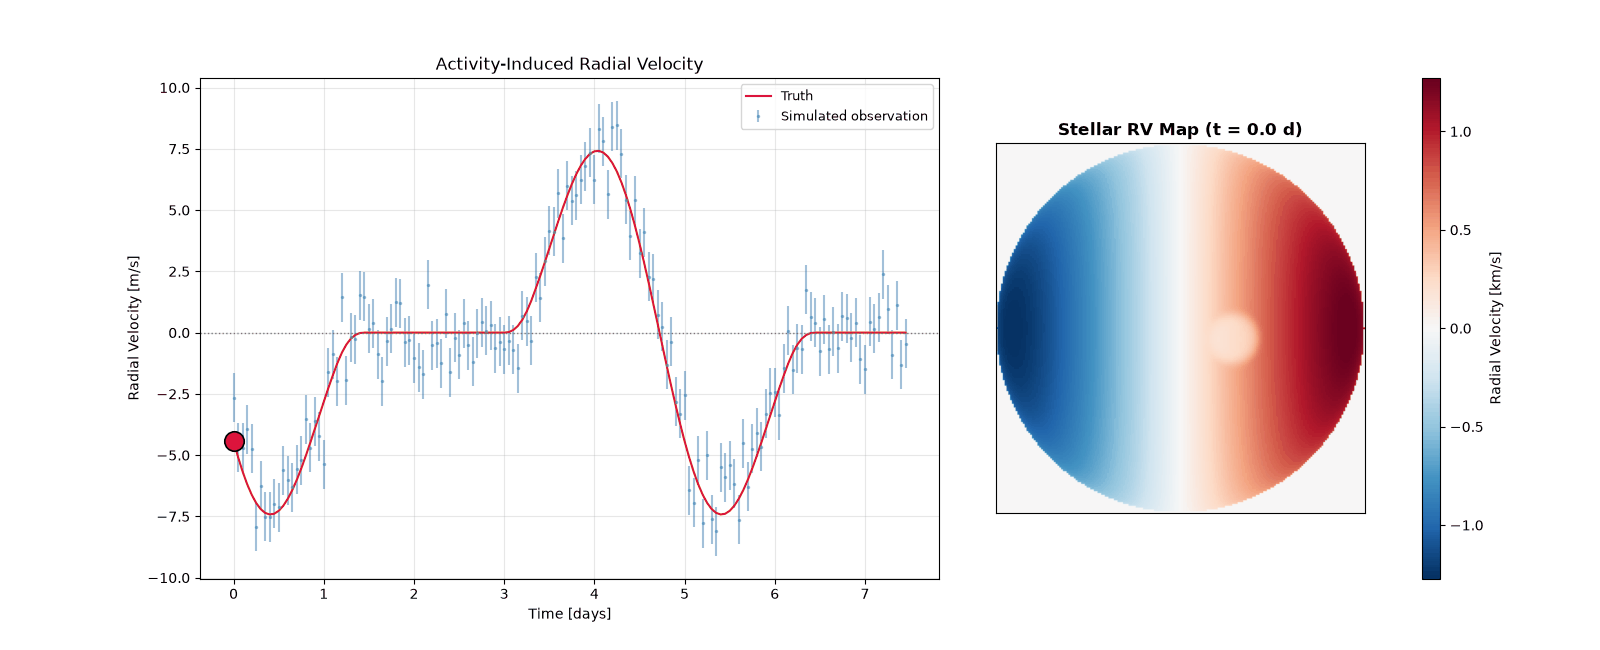

In [5]:
# ---- Plot: radial-velocity curve + star map --------------
fig, axes = plt.subplot_mosaic(
    [['A', 'B', 'cbar']], figsize=(16, 6.5),
    width_ratios=[2, 1, 0.05], gridspec_kw={'wspace': 0.15},
)

axes['A'].errorbar(times, rv_obs, yerr=rv_err, fmt='.', ms=3, color='steelblue', alpha=0.5, label='Simulated observation')
axes['A'].plot(times, rv_true, '-', color='crimson', lw=1.5, label='Truth')
axes['A'].axhline(0.0, color='gray', linewidth=1, linestyle=':')
phase_marker, = axes['A'].plot([times[0]], [rv_true[0]], 'o', markersize=14,
                                color='crimson', markeredgecolor='black',
                                markeredgewidth=1.2, zorder=5)
axes['A'].set_xlabel('Time [days]'); axes['A'].set_ylabel('Radial Velocity [m/s]')
axes['A'].set_title('Activity-Induced Radial Velocity'); axes['A'].legend(fontsize=9)
axes['A'].grid(alpha=0.3)

im_B = axes['B'].imshow(star_maps[0], cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
map_title = axes['B'].set_title(f'Stellar RV Map (t = {times[0]:.1f} d)', fontsize=12, fontweight='bold')
axes['B'].set_xticks([]); axes['B'].set_yticks([])
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=axes['cbar'], label='Radial Velocity [km/s]')

def _update(frame):
    phase_marker.set_data([times[frame]], [rv_true[frame]])
    im_B.set_data(star_maps[frame])
    map_title.set_text(f'Stellar RV Map (t = {times[frame]:.1f} d)')
    return phase_marker, im_B, map_title

frame_idx = list(range(0, len(times), 3))
anim = FuncAnimation(fig, _update, frames=frame_idx, interval=80, blit=False)

with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as _tmp:
    gif_path = _tmp.name
anim.save(gif_path, writer=PillowWriter(fps=15))
plt.close(fig)
with open(gif_path, 'rb') as f:
    gif_bytes = f.read()
os.remove(gif_path)

display(Image(data=gif_bytes, format='gif'))

## Fitting Method

The inference below can be done two ways:

* **`"map"`** (default) - a fast maximum a posteriori (MAP) point estimate found via gradient-based optimization (`numpyro_ext.optim`, using `jaxopt`'s L-BFGS under the hood). As this takes only a few seconds-minutes, it keeps the notebook quick to run end-to-end.
  
* **`"nuts"`** - the full posterior via NUTS MCMC, giving real uncertainties and the corner/trace plots below, at the cost of much longer runtime (on the order of hours for the current setup). See the "Runtime tuning" cell further down to learn about the key `SAJAX` knobs to turn to speed this up.

Switch `FIT_METHOD` and re-run from here on to change which one is used.

In [6]:
FIT_METHOD = "map"   # "map" or "nuts"
assert FIT_METHOD in ("map", "nuts")

## Fit: Spot Position, Size, and Contrast from the RV Curve

We fit for the spot's latitude, longitude, size, and contrast, with the limb-darkening coefficients fixed at their (independently known, e.g. from `exotic-ld`) true values.

In [7]:
# Define the forward model for the radial-velocity curve
def model_rv(yerr, y=None):

    # Priors for the parameters we're fitting for
    # Active region latitude
    sin_ar_lat = numpyro.sample("sin_ar_lat", dist.Uniform(-1., 1.))

    # Active region longitude
    ar_long = numpyro.sample("ar_long", dist.Uniform(-180., 180.))

    # Active region size
    ar_size = numpyro.sample("ar_size", dist.Uniform(2., 30.))

    # Active region contrast
    ar_contrast = numpyro.sample("ar_contrast", dist.Uniform(0., 2.))

    # Radial-velocity curve
    y_pred = make_rv(
        rv_model,
        flux_active   = ar_contrast,
        ar_lat        = jnp.rad2deg(jnp.arcsin(sin_ar_lat)),
        ar_long       = ar_long,
        ar_size       = ar_size,
        ar_smoothness = AR_SMOOTH_TRUE,
    )[0] * 1000.0   # km/s -> m/s

    # Track the radial-velocity curve
    numpyro.deterministic("rv_curve", y_pred)

    # The likelihood function assuming Gaussian uncertainty
    numpyro.sample("obs", dist.Normal(y_pred, yerr), obs=y)

# Bounds from which to sample the initial position
INIT_POSITIONS_BOUNDS = {
    "sin_ar_lat":  [jnp.sin(jnp.deg2rad(AR_LAT_TRUE - 10.)), jnp.sin(jnp.deg2rad(AR_LAT_TRUE + 10.))],
    "ar_long":     [AR_LONG_TRUE - 10., AR_LONG_TRUE + 10.],
    "ar_size":     [jnp.maximum(AR_SIZE_TRUE - 5., 0.), AR_SIZE_TRUE + 5.],
    "ar_contrast": [jnp.maximum(contrast_white - 0.2, 0.), contrast_white + 0.2],
}
# Initial positions
init_pos_key = jax.random.PRNGKey(12)
init_pos = {
    name: jax.random.uniform(init_pos_key, minval=lo, maxval=hi)
    for name, (lo, hi) in INIT_POSITIONS_BOUNDS.items()
}

if FIT_METHOD == "nuts":
    # Full posterior via NUTS MCMC
    sampler = numpyro.infer.MCMC(
        numpyro.infer.NUTS(
            model_rv,
            dense_mass=True,
            regularize_mass_matrix=True,
            init_strategy=numpyro.infer.init_to_value(values=init_pos),
        ),
        num_warmup=100,
        num_samples=400,
        num_chains=2,
        progress_bar=True,
    )
    sampler.run(jax.random.PRNGKey(0), jnp.asarray(rv_err),
                   y=jnp.asarray(rv_obs), extra_fields=("potential_energy",))
else:
    # MAP point estimate via gradient-based optimization.
    run_geom = optimx.optimize(
        model_rv,
        sites=["sin_ar_lat", "ar_long", "ar_size"],
        start=init_pos,
    )
    soln_geom = run_geom(jax.random.PRNGKey(0), jnp.asarray(rv_err), y=jnp.asarray(rv_obs))

    run_joint = optimx.optimize(model_rv, start={name: soln_geom[name] for name in init_pos})
    soln_rv = run_joint(jax.random.PRNGKey(1), jnp.asarray(rv_err), y=jnp.asarray(rv_obs))

## Summary and Traces

In [8]:
if FIT_METHOD == "nuts":
    # Formatting samples
    inf_data = az.from_numpyro(sampler)
    inf_data.posterior["ar_lat"] = np.rad2deg(np.arcsin(inf_data.posterior["sin_ar_lat"].clip(-1.0, 1.0)))

    # Making nice display names for the parameters in the corner plot and ArviZ summary
    display_names = {
        "ar_lat": r"$\phi_{\rm ar}$ [deg]", "ar_long": r"$\lambda_{\rm ar}$ [deg]",
        "ar_size": r"$r_{\rm ar}$ [deg]", "ar_contrast": r"$C_{\rm ar}$",
    }
    inf_data.posterior = inf_data.posterior[list(display_names)].rename(display_names)
    param_names = list(display_names.values())

    # Showing summary
    sampler.print_summary()

    # Plotting traces
    _ = az.plot_trace(
        inf_data,
        var_names=param_names,
        backend_kwargs={"constrained_layout": True},
    )
else:
    # MAP: no posterior to summarize/trace over -- report the point
    # estimate against the ground truth for each fitted parameter instead.
    map_summary = {
        "ar_lat [deg]":  (float(jnp.rad2deg(jnp.arcsin(soln_rv["sin_ar_lat"]))), AR_LAT_TRUE),
        "ar_long [deg]": (float(soln_rv["ar_long"]), AR_LONG_TRUE),
        "ar_size [deg]": (float(soln_rv["ar_size"]), AR_SIZE_TRUE),
        "ar_contrast":   (float(soln_rv["ar_contrast"]), float(contrast_white)),
    }
    print(f"{'parameter':<18s}{'MAP':>12s}{'truth':>12s}")
    for name, (map_val, truth_val) in map_summary.items():
        print(f"{name:<18s}{map_val:>12.4f}{truth_val:>12.4f}")

    # Fit quality check
    rv_map_pred = jnp.asarray(soln_rv["rv_curve"])
    chi2_map   = float(jnp.sum(((jnp.asarray(rv_obs) - rv_map_pred) / SIGMA) ** 2))
    chi2_truth = float(jnp.sum(((jnp.asarray(rv_obs) - rv_true) / SIGMA) ** 2))
    print(f"\nchi^2 at MAP:   {chi2_map:.1f}  ({len(rv_obs)} points)")
    print(f"chi^2 at truth: {chi2_truth:.1f}")

parameter                  MAP       truth
ar_lat [deg]           28.4306     30.0000
ar_long [deg]          18.4678     20.0000
ar_size [deg]           5.6045      8.0000
ar_contrast             0.0157      0.4854

chi^2 at MAP:   147.7  (150 points)
chi^2 at truth: 158.5


## Corner Plot and Best-fit Radial Velocity Curves

With `FIT_METHOD = "nuts"`, this shows the full posterior corner plot (with truth/posterior-median/MAP marked on every panel), followed by the best-fit radial velocity curve, residuals, and a rotating stellar-flux-map animation at the posterior-median (and MAP) parameters.

With `FIT_METHOD = "map"`, the corner plot is skipped -- there's no distribution to show, just a single point estimate -- straight to the best-fit radial velocity curve, residuals, and star-map animation at the MAP parameters.

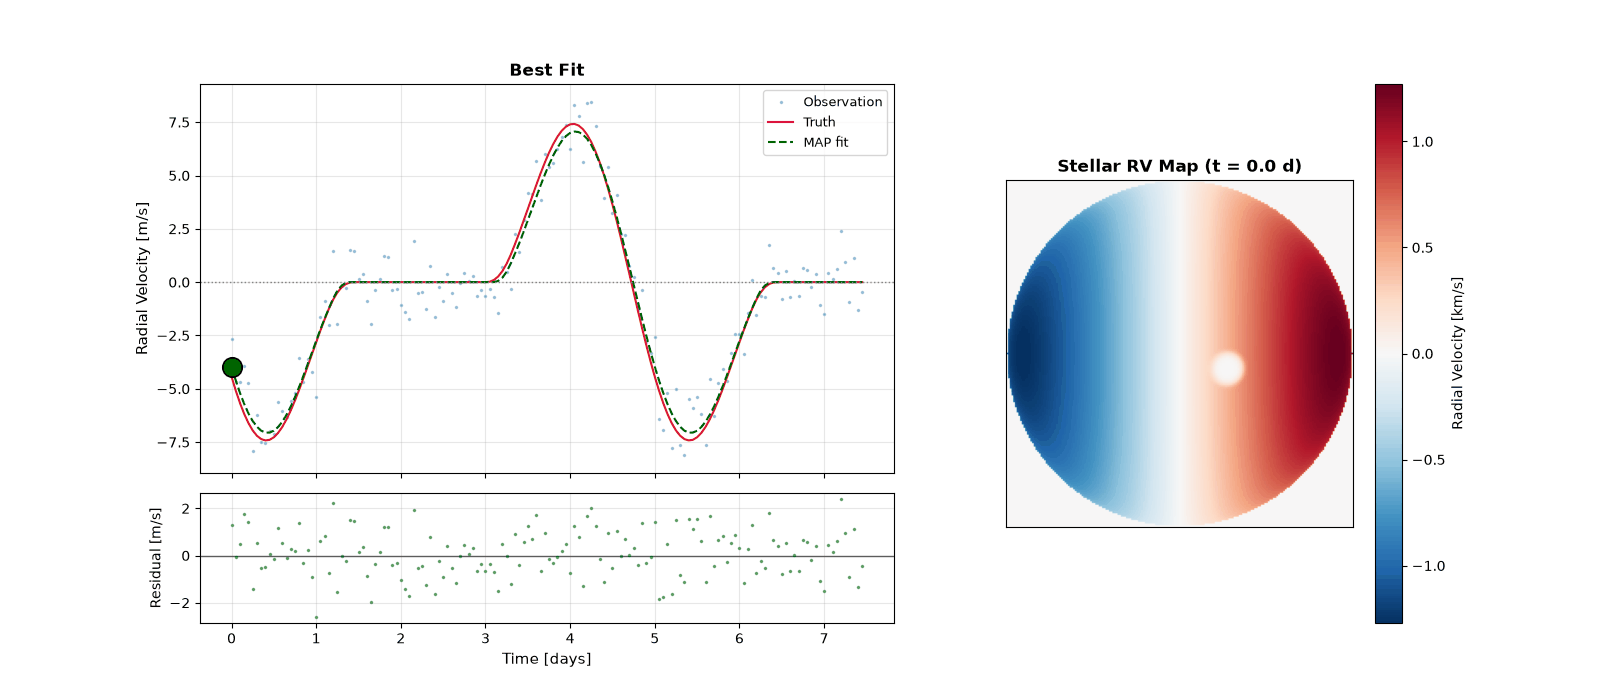

In [9]:
if FIT_METHOD == "nuts":
    # Build a dictionary for the true parameter values
    truths_rv = dict(
        ar_lat=AR_LAT_TRUE, ar_long=AR_LONG_TRUE, ar_size=AR_SIZE_TRUE, ar_contrast=contrast_white,
    )

    # Retrieve the samples, and MAP index from the sampler
    samples = sampler.get_samples()
    map_idx = int(np.argmin(np.array(sampler.get_extra_fields()["potential_energy"])))

    # ---- Corner plot with truth/median/MAP overlaid on every panel ----
    corner_samples = {
        "ar_lat":      np.rad2deg(np.arcsin(np.clip(np.array(samples["sin_ar_lat"]), -1.0, 1.0))),
        "ar_long":     np.array(samples["ar_long"]),
        "ar_size":     np.array(samples["ar_size"]),
        "ar_contrast": np.array(samples["ar_contrast"]),
    }
    corner_truths = {name: truths_rv[name] for name in corner_samples}

    samples_arr = np.stack([corner_samples[name] for name in corner_samples.keys()], axis=-1)
    truths_arr  = [float(corner_truths[name]) for name in corner_samples.keys()]
    median_arr  = [float(np.median(corner_samples[name])) for name in corner_samples.keys()]
    map_arr     = [float(corner_samples[name][map_idx]) for name in corner_samples.keys()]

    # Generate corner plot -- look for the ar_size/ar_contrast panel in
    # particular: a diagonal banana-shaped correlation there is the
    # size-contrast degeneracy flagged above, not a fitting problem.
    fig = corner.corner(
        samples_arr, labels=param_names, truths=truths_arr,
        show_titles=True, title_fmt='.4f',
        label_kwargs={'fontsize': 14}, title_kwargs={'fontsize': 11},
    )

    corner.overplot_lines(fig, median_arr, color='darkorange', linestyle='--', linewidth=1.2)
    corner.overplot_points(fig, [median_arr], marker='s', color='darkorange', markersize=6)
    corner.overplot_lines(fig, map_arr, color='mediumseagreen', linestyle='-.', linewidth=1.2)
    corner.overplot_points(fig, [map_arr], marker='D', color='mediumseagreen', markersize=6)

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color='#4682b4', label='Truth'),
        Line2D([0], [0], color='darkorange', linestyle='--', label='Posterior median'),
        Line2D([0], [0], color='mediumseagreen', linestyle='-.', label='MAP'),
    ]
    fig.legend(handles=legend_handles, loc='upper right', fontsize=14, bbox_to_anchor=(0.98, 0.98))
    plt.show()

    # Posterior-median and MAP radial-velocity curves + residuals
    rv_samples_all          = jnp.array(samples["rv_curve"])   # (num_samples, ntimes)
    rv_bestfit               = jnp.median(rv_samples_all, axis=0)
    rv_map                   = rv_samples_all[map_idx]
    residuals_bestfit        = jnp.array(rv_obs) - rv_bestfit
    residuals_map            = jnp.array(rv_obs) - rv_map

    # The point estimate used for the best-fit map/curve below: posterior medians here
    median_rv = {name: float(jnp.median(arr)) for name, arr in samples.items() if arr.ndim == 1}
    median_rv["ar_lat"] = float(jnp.rad2deg(jnp.arcsin(median_rv["sin_ar_lat"])))
else:
    # MAP point estimate radial-velocity curve + residuals
    median_rv = {
        "ar_lat":      float(jnp.rad2deg(jnp.arcsin(soln_rv["sin_ar_lat"]))),
        "ar_long":     float(soln_rv["ar_long"]),
        "ar_size":     float(soln_rv["ar_size"]),
        "ar_contrast": float(soln_rv["ar_contrast"]),
    }
    rv_bestfit        = jnp.array(soln_rv["rv_curve"])   # (ntimes,) -- straight from the model
    residuals_bestfit = jnp.array(rv_obs) - rv_bestfit

# ---- Best-fit RV map + radial-velocity curve (shared by both fitting methods) ----
result_bestfit = make_rv(
    rv_model,
    flux_active   = median_rv["ar_contrast"],
    ar_lat        = median_rv["ar_lat"],
    ar_long       = median_rv["ar_long"],
    ar_size       = median_rv["ar_size"],
    ar_smoothness = AR_SMOOTH_TRUE,
)
star_maps_bestfit  = jnp.asarray(result_bestfit[1])
rv_extent_bf       = float(jnp.max(jnp.abs(star_maps_bestfit)))
vmin_bf, vmax_bf   = -rv_extent_bf, rv_extent_bf

# Plotting
fig, axes = plt.subplot_mosaic(
    [['RV', 'MAP'], ['RESID', 'MAP']],
    figsize=(16, 7), height_ratios=[3, 1], width_ratios=[1.6, 1],
    gridspec_kw={'hspace': 0.08}, sharex=False,
)
ax_rv, ax_resid, ax_map = axes['RV'], axes['RESID'], axes['MAP']

# Radial-velocity panel with the truth, noisy observations, and best fit
ax_rv.plot(times, rv_obs, '.', ms=3, color='steelblue', alpha=0.4, label='Observation')
ax_rv.plot(times, rv_true, '-', color='crimson', lw=1.5, label='Truth')
ax_rv.plot(times, rv_bestfit, '--', color='darkgreen', lw=1.5,
           label='Posterior-median fit' if FIT_METHOD == 'nuts' else 'MAP fit')
if FIT_METHOD == 'nuts':
    ax_rv.plot(times, rv_map, '-.', color='mediumseagreen', lw=1.5, label='MAP fit')
ax_rv.axhline(0.0, color='gray', linewidth=1, linestyle=':')
phase_marker, = ax_rv.plot([times[0]], [rv_bestfit[0]], 'o', markersize=14,
                           color='darkgreen', markeredgecolor='black',
                           markeredgewidth=1.2, zorder=5)
ax_rv.set_ylabel('Radial Velocity [m/s]', fontsize=11)
ax_rv.set_title('Best Fit', fontsize=12, fontweight='bold')
ax_rv.legend(fontsize=9); ax_rv.grid(alpha=0.3)
ax_rv.tick_params(labelbottom=False)
ax_rv.sharex(ax_resid)

# Residuals panel
ax_resid.axhline(0.0, color='black', lw=1.0, alpha=0.6)
ax_resid.plot(times, residuals_bestfit, '.', ms=3, color='darkgreen', alpha=0.5)
if FIT_METHOD == 'nuts':
    ax_resid.plot(times, residuals_map, '.', ms=3, color='mediumseagreen', alpha=0.5)
ax_resid.set_xlabel('Time [days]', fontsize=11); ax_resid.set_ylabel('Residual [m/s]', fontsize=10)
ax_resid.grid(alpha=0.3)

# Stellar RV map panel
im = ax_map.imshow(star_maps_bestfit[0], cmap='RdBu_r', origin='lower', vmin=vmin_bf, vmax=vmax_bf)
map_title = ax_map.set_title(f'Stellar RV Map (t = {times[0]:.1f} d)', fontsize=12, fontweight='bold')
ax_map.set_xticks([]); ax_map.set_yticks([])
plt.colorbar(im, ax=ax_map, label='Radial Velocity [km/s]')

def _update(frame):
    phase_marker.set_data([times[frame]], [rv_bestfit[frame]])
    im.set_data(star_maps_bestfit[frame])
    map_title.set_text(f'Stellar RV Map (t = {times[frame]:.1f} d)')
    return phase_marker, im, map_title
frame_idx = list(range(0, len(times), 3))
anim = FuncAnimation(fig, _update, frames=frame_idx, interval=80, blit=False)

with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as _tmp:
    gif_path = _tmp.name
anim.save(gif_path, writer=PillowWriter(fps=30))
plt.close(fig)
with open(gif_path, 'rb') as f:
    gif_bytes = f.read()
os.remove(gif_path)

display(Image(data=gif_bytes, format='gif'))